# Exploración CLR y PCA: taxonomía y funciones

La preparación es distinta para géneros MetaPhlAn y rutas funcionales HUMAnN,
pero ambas usan el mismo análisis modular: limpiar muestras, amalgamar rasgos
raros en `Other`, aplicar CLR, ajustar PCA, crear el biplot y exportar salidas.

En cada sección, cambia `ARROW_LABELS` según lo que quieras mostrar en las
flechas: `"names"`, `"numbers"` o `"none"`. Cuando se usan números, se guarda
una tabla de referencias en `results/tables/02_clr_pca_exploration/`.


In [21]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

DATASETS = PROJECT_ROOT / "datasets"
FIGURES = PROJECT_ROOT / "results" / "figures" / "02_clr_pca_exploration"
TABLES = PROJECT_ROOT / "results" / "tables" / "02_clr_pca_exploration"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

METADATA = pd.read_excel(DATASETS / "metadata_LATINBIOTA_MEXICO.xlsx", sheet_name="Data")
OUTLIERS = [
    "37082_3#16", "37082_2#4", "37035_2#22",
    "37035_7#18", "36703_3#20", "36703_3#4",
]


## Funciones comunes


In [22]:
def remove_outlier_samples(abundance, outliers):
    # Elimina exclusivamente las muestras listadas como atípicas.
    return abundance.drop(index=outliers, errors="ignore").copy()


def keep_samples_with_lifestyle(abundance, metadata):
    # Alinea abundancias y conserva únicamente Rural/Urban.
    lifestyle = metadata.set_index("Lane")["Lifestyle"].reindex(abundance.index)
    valid = lifestyle.isin(["Rural", "Urban"])
    return abundance.loc[valid].copy(), lifestyle.loc[valid].copy()


def amalgamate_rare_features(abundance, prevalence=0.05, other_name="Other"):
    # Agrupa en Other las características presentes en pocas muestras.
    minimum_samples = max(1, int(np.ceil(prevalence * len(abundance))))
    keep = (abundance > 0).sum(axis=0) >= minimum_samples
    rare = abundance.columns[~keep]
    result = abundance.loc[:, abundance.columns[keep]].copy()
    if len(rare):
        result[other_name] = abundance.loc[:, rare].sum(axis=1)
    return result


def apply_clr(abundance):
    # Aplica CLR con pseudoconteo igual a la mitad del mínimo positivo.
    positive_values = abundance.where(abundance > 0).stack()
    if positive_values.empty:
        raise ValueError("No hay abundancias positivas para aplicar CLR.")
    pseudocount = positive_values.min() / 2
    log_abundance = np.log(abundance + pseudocount)
    return log_abundance.sub(log_abundance.mean(axis=1), axis=0)


def fit_pca(clr_data):
    # Ajusta PCA y calcula la contribución como |PC1| + |PC2|, igual que el original.
    pca = PCA(n_components=2)
    scores = pd.DataFrame(pca.fit_transform(clr_data), index=clr_data.index, columns=["PC1", "PC2"])
    loadings = pd.DataFrame(pca.components_.T, index=clr_data.columns, columns=["PC1", "PC2"])
    loadings["contribution"] = loadings[["PC1", "PC2"]].abs().sum(axis=1)
    return pca, scores, loadings.sort_values("contribution", ascending=False)


def select_distinct_directions(loadings, top_candidates=30, distance_threshold=0.1):
    # Agrupa las cargas principales por dirección coseno y elige un representante por grupo.
    candidates = loadings.head(min(top_candidates, len(loadings))).copy()
    if len(candidates) < 2:
        groups = np.ones(len(candidates), dtype=int)
    else:
        distances = pdist(candidates[["PC1", "PC2"]].to_numpy(), metric="cosine")
        groups = fcluster(linkage(distances, method="average"), distance_threshold, criterion="distance")

    directions = []
    for group_id in np.unique(groups):
        members = candidates.iloc[np.where(groups == group_id)[0]]
        representative = members["contribution"].idxmax()
        feature_names = list(members.index)
        feature_names.sort(key=lambda name: (str(name).startswith("GGB"), -members.loc[name, "contribution"]))
        directions.append({
            "representative": representative,
            "features": feature_names,
            "PC1": loadings.loc[representative, "PC1"],
            "PC2": loadings.loc[representative, "PC2"],
            "contribution": loadings.loc[representative, "contribution"],
        })
    return pd.DataFrame(directions).sort_values("contribution", ascending=False).reset_index(drop=True)


def format_direction_name(features, max_names=3):
    # Resume los nombres asociados a una dirección para evitar etiquetas demasiado largas.
    if len(features) <= max_names:
        return "\n".join(features)
    return "\n".join(features[:max_names]) + f"\n(+{len(features) - max_names} más)"


def plot_pca_biplot(scores, lifestyle, directions, pca, title,
                    arrow_labels="names", arrow_scale=100, figure_size=(8, 8), dpi=300):
    # Reproduce el estilo de los biplots originales.
    if arrow_labels not in {"names", "numbers", "none"}:
        raise ValueError("arrow_labels debe ser 'names', 'numbers' o 'none'.")

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 10,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
    })
    fig, ax = plt.subplots(figsize=figure_size, dpi=dpi)
    colors = plt.cm.Set2.colors
    label_translation = {"Rural": "Rural", "Urban": "Urbano"}

    ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5, zorder=1)
    ax.axvline(0, color="gray", linewidth=0.5, alpha=0.5, zorder=1)

    for color_index, group in enumerate(sorted(lifestyle.unique())):
        points = scores.loc[lifestyle.eq(group)]
        ax.scatter(points.PC1, points.PC2, label=label_translation.get(group, group),
                   color=colors[color_index % len(colors)], s=60, alpha=0.7,
                   edgecolor="white", linewidth=0.7, zorder=3)

    references = []
    for number, row in directions.iterrows():
        reference = number + 1
        x, y = row.PC1 * arrow_scale, row.PC2 * arrow_scale
        ax.annotate("", xy=(x, y), xytext=(0, 0),
                    arrowprops={"arrowstyle": "->", "lw": 2.5, "color": "darkred",
                                "mutation_scale": 25, "alpha": 0.7}, zorder=4)

        if arrow_labels == "names":
            ax.text(x * 1.12, y * 1.12, format_direction_name(row.features),
                    fontsize=7 if len(row.features) > 1 else 8, color="darkred",
                    ha="center", va="center", fontweight="bold",
                    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white",
                          "edgecolor": "darkred", "alpha": 0.92, "linewidth": 1}, zorder=5)
        elif arrow_labels == "numbers":
            ax.text(x * 1.05, y * 1.05, str(reference), fontsize=11.5, color="white",
                    ha="center", va="center", fontweight="bold",
                    bbox={"boxstyle": "circle,pad=0.3", "facecolor": "darkred",
                          "edgecolor": "white", "alpha": 0.9, "linewidth": 1.5}, zorder=5)

        references.append({
            "reference": reference,
            "representative": row.representative,
            "features": ", ".join(row.features),
            "contribution": row.contribution,
            "PC1": row.PC1,
            "PC2": row.PC2,
        })

    ax.set_aspect("equal", adjustable="box")
    ax.axis("equal")
    ax.set_xlabel(f"CP1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12, fontweight="bold")
    ax.set_ylabel(f"CP2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.legend(title="Grupos", loc="best", fontsize=10, title_fontsize=11,
              frameon=True, edgecolor="black", fancybox=False, framealpha=0.95)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    return fig, pd.DataFrame(references)


def export_pca_results(name, scores, lifestyle, loadings, references, figure):
    # Guarda coordenadas, cargas, referencias de flechas y figura final.
    scores.assign(Lifestyle=lifestyle).to_csv(TABLES / f"{name}_pca_scores.csv")
    loadings.to_csv(TABLES / f"{name}_pca_loadings.csv")
    references.to_csv(TABLES / f"{name}_arrow_references.csv", index=False)
    figure.savefig(FIGURES / f"{name}_clr_pca_biplot.png", dpi=300, bbox_inches="tight")
    figure.savefig(FIGURES / f"{name}_clr_pca_biplot.pdf", bbox_inches="tight")


def run_clr_pca(abundance, name, title, prevalence=0.1, top_candidates=30,
                distance_threshold=0.1, arrow_labels="names", arrow_scale=100,
                figure_size=(8, 8), dpi=300):
    # Orquesta el flujo común usando las mismas direcciones distintivas del original.
    abundance = abundance.apply(pd.to_numeric, errors="coerce").fillna(0)
    abundance = remove_outlier_samples(abundance, OUTLIERS)
    abundance, lifestyle = keep_samples_with_lifestyle(abundance, METADATA)
    abundance = amalgamate_rare_features(abundance, prevalence=prevalence)
    clr_data = apply_clr(abundance)
    pca, scores, loadings = fit_pca(clr_data)
    directions = select_distinct_directions(loadings, top_candidates, distance_threshold)
    figure, references = plot_pca_biplot(
        scores, lifestyle, directions, pca, title, arrow_labels=arrow_labels,
        arrow_scale=arrow_scale, figure_size=figure_size, dpi=dpi,
    )
    export_pca_results(name, scores, lifestyle, loadings, references, figure)
    plt.show()

    print(f"{name}: {len(abundance)} muestras, {abundance.shape[1]} características, "
          f"PC1+PC2 = {pca.explained_variance_ratio_[:2].sum():.1%}")
    print(f"Direcciones seleccionadas: {len(directions)} de {min(top_candidates, len(loadings))} candidatas.")
    if arrow_labels == "numbers":
        print("Referencias de las flechas:")
        print(references[["reference", "features"]].to_string(index=False))
    return {"scores": scores.assign(Lifestyle=lifestyle), "loadings": loadings,
            "directions": directions, "references": references, "clr": clr_data, "pca": pca}


## 1. Taxonomía: géneros de MetaPhlAn


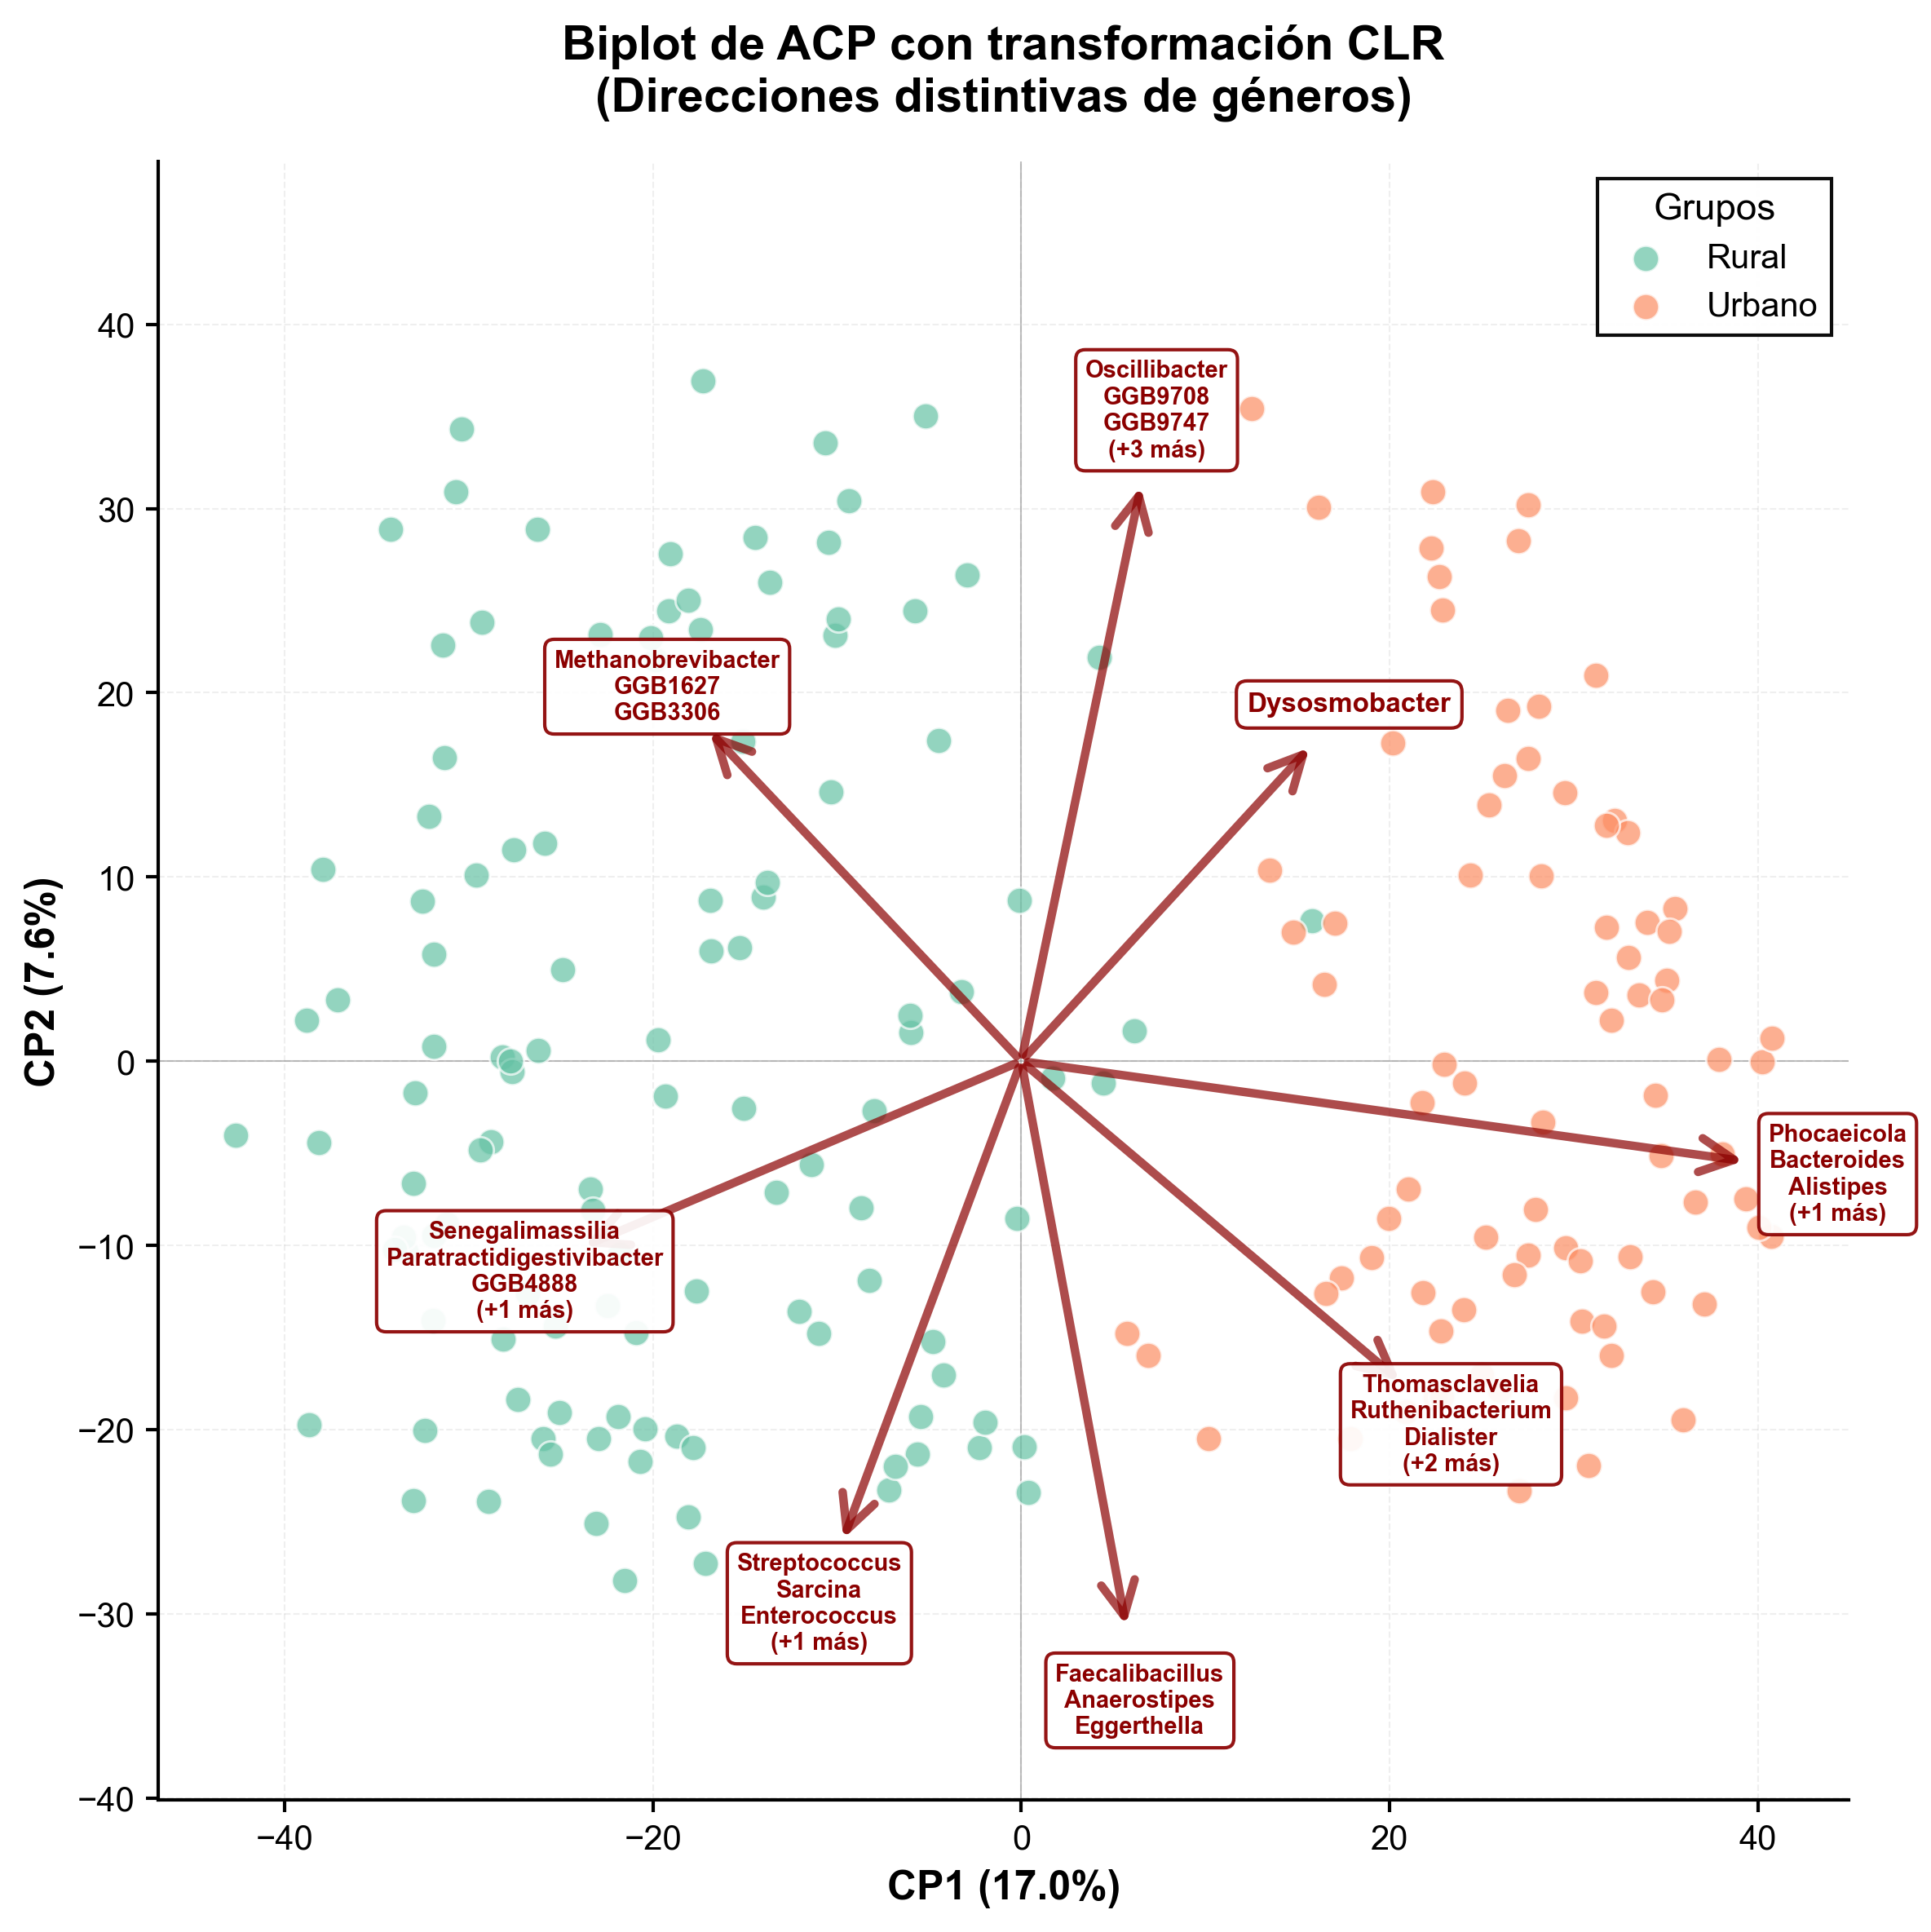

taxonomic_genus: 199 muestras, 432 características, PC1+PC2 = 24.6%
Direcciones seleccionadas: 8 de 30 candidatas.


,PC1,PC2,contribution
Phocaeicola,0.197876,-0.027372,0.225249
Bacteroides,0.190373,0.011394,0.201767
Thomasclavelia,0.104159,-0.088013,0.192172
GGB9708,0.032799,0.157745,0.190544
Alistipes,0.179625,0.005270,0.184895
Faecalibacillus,0.028734,-0.154931,0.183665
Ruthenibacterium,0.131499,-0.051457,0.182957
GGB3109,0.095019,-0.086556,0.181575
Streptococcus,-0.048939,-0.131380,0.180319
Anaerostipes,0.064945,-0.113287,0.178233


In [23]:
# Preparación exclusiva de MetaPhlAn: taxones × muestras → géneros × muestras.
ARROW_LABELS = "names"  # Elegir: "names", "numbers" o "none".

metaphlan = pd.read_csv(DATASETS / "latinbiota_merge_metaphlan_data.csv", sep="\t", skiprows=1, index_col=0)
taxon_names = metaphlan.index.astype(str)
is_genus = (
    taxon_names.str.contains(r"(?:^|\|)g__", regex=True)
    & ~taxon_names.str.contains(r"(?:^|\|)[ts]__", regex=True)
    & ~taxon_names.str.contains("unclassified", case=False)
)
genus = metaphlan.loc[is_genus].copy()
genus.index = [name.split("|g__", 1)[1].split("|", 1)[0].replace("_", " ") for name in genus.index]
genus = genus.groupby(level=0).sum().T

genus_result = run_clr_pca(
    genus, "taxonomic_genus", "Biplot de ACP con transformación CLR\n(Direcciones distintivas de géneros)",
    arrow_labels=ARROW_LABELS, arrow_scale=200, figure_size=(8, 8), dpi=300,
)
genus_result["loadings"].head(10)


## 2. Funcional: rutas no estratificadas de HUMAnN


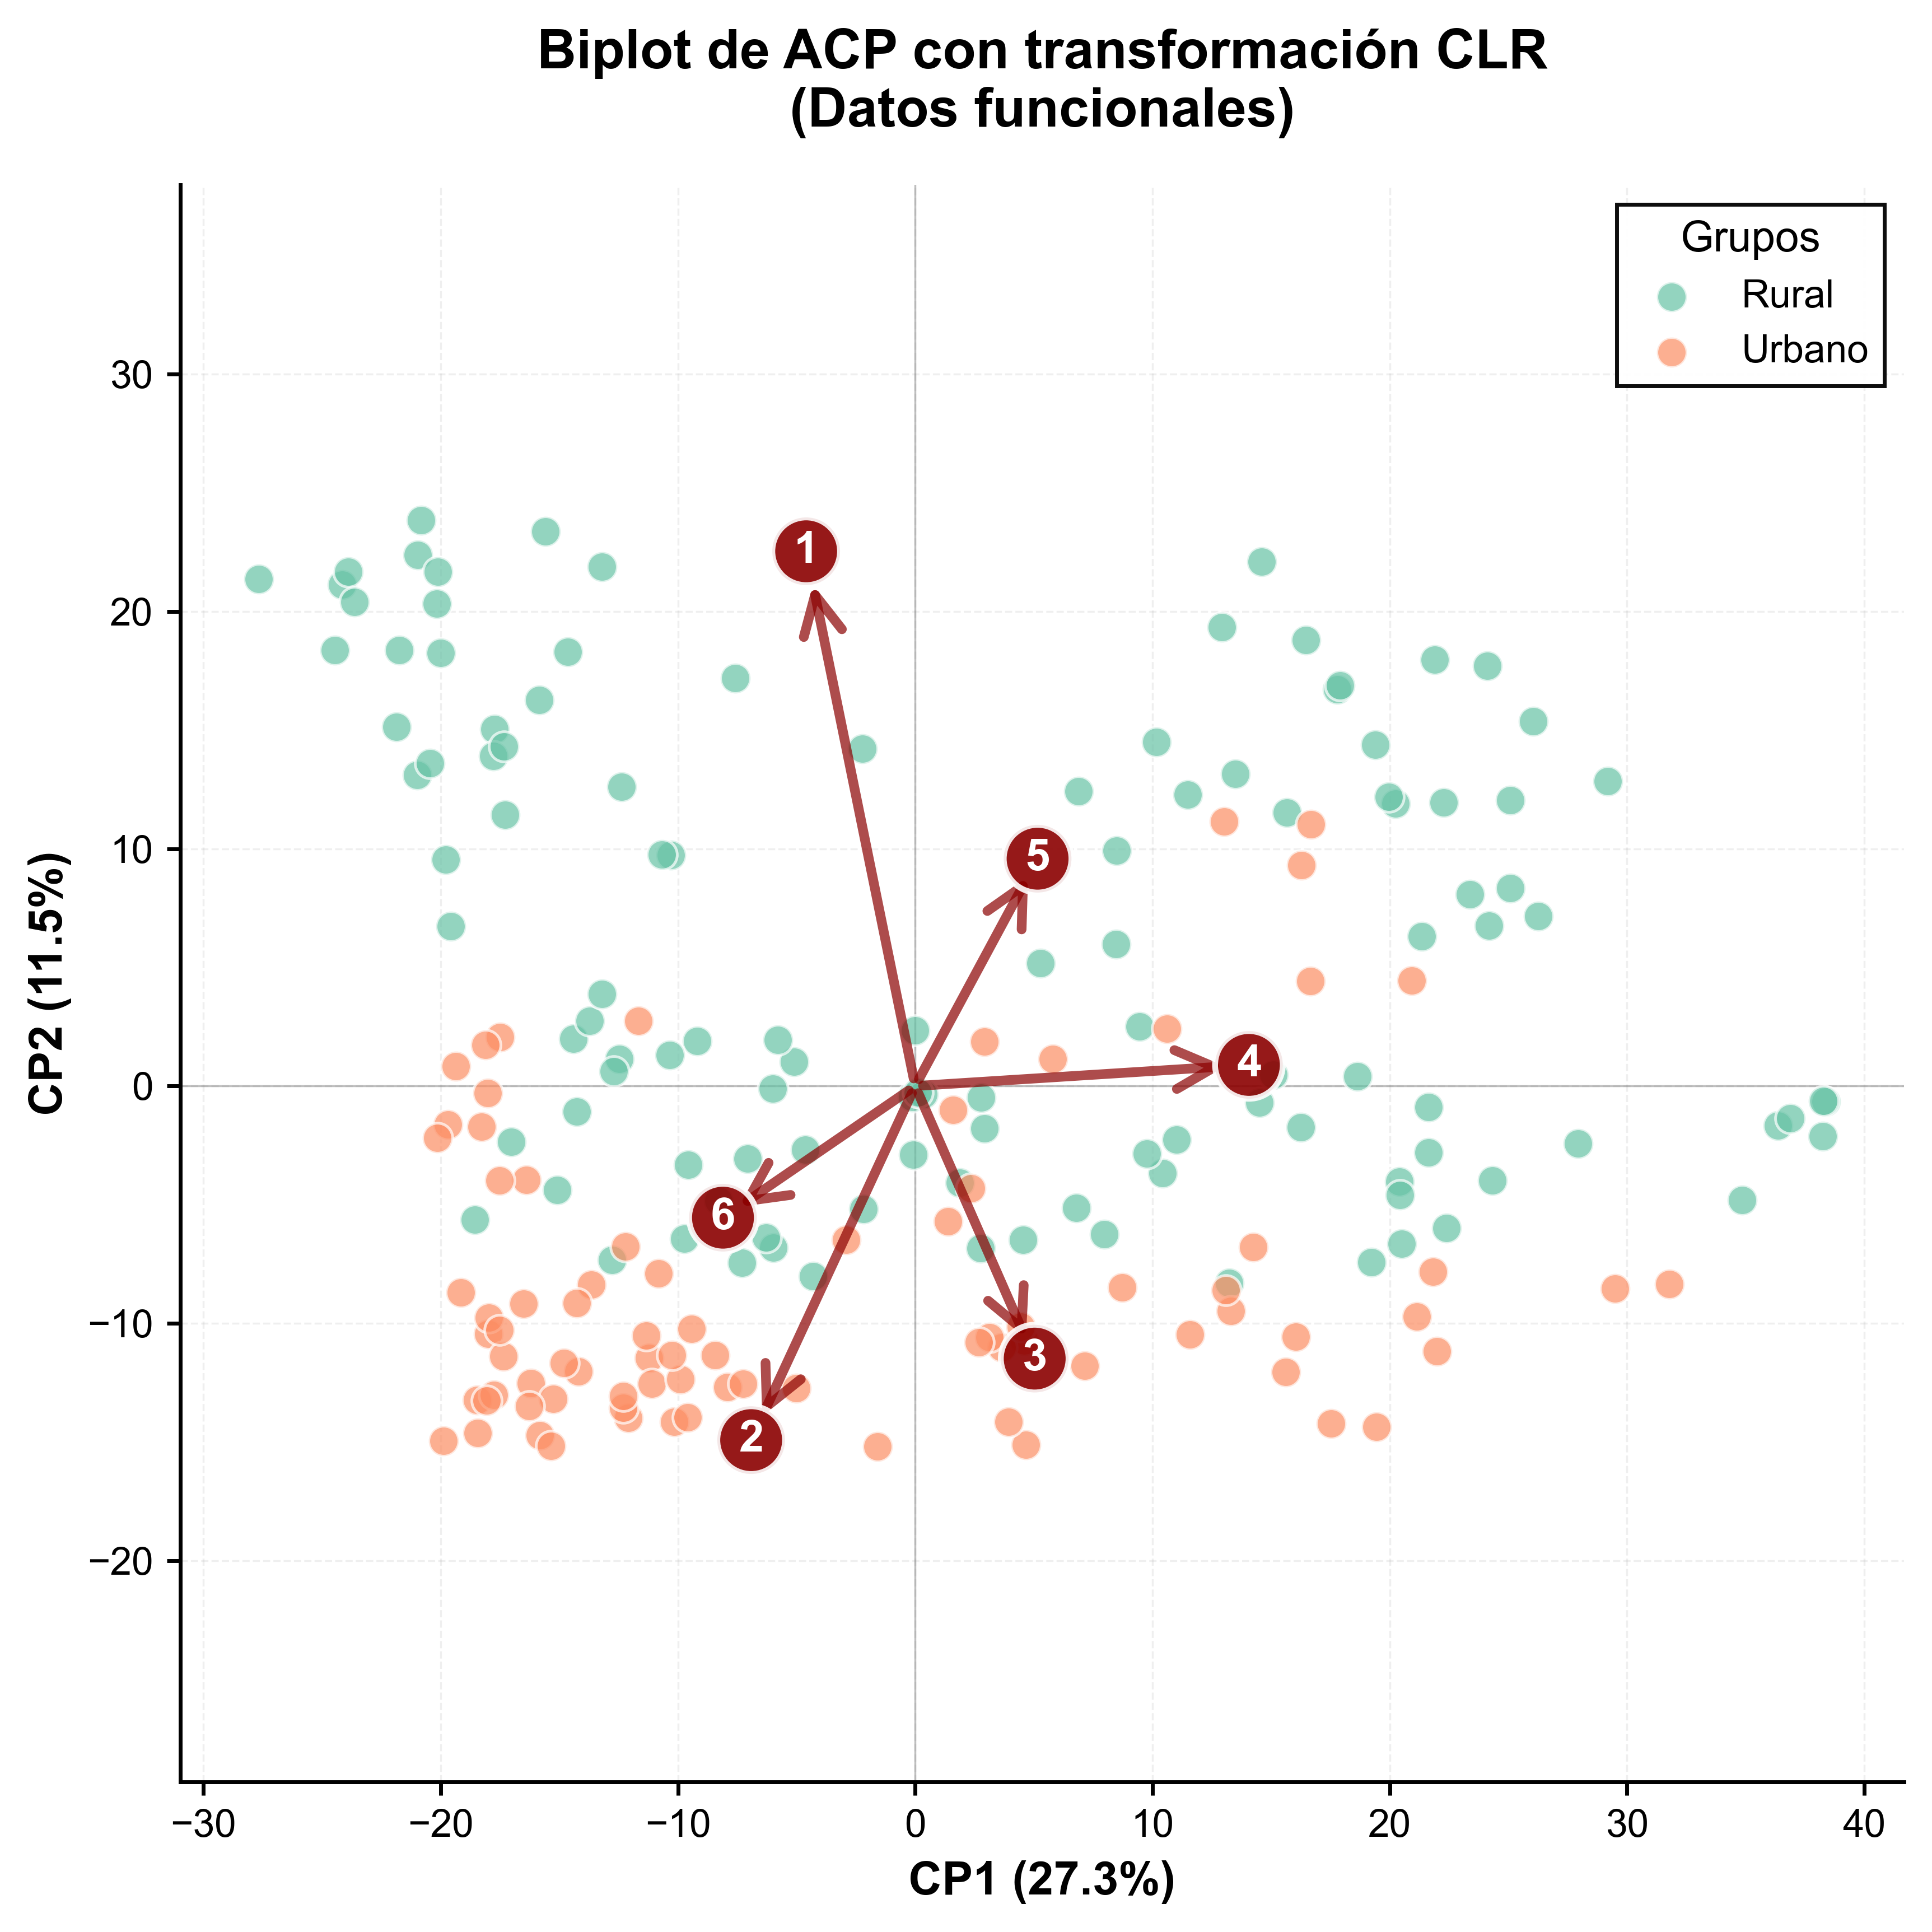

functional_pathways: 199 muestras, 455 características, PC1+PC2 = 38.8%
Direcciones seleccionadas: 6 de 30 candidatas.
Referencias de las flechas:
 reference                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    features
         1 PWY

,PC1,PC2,contribution
# Pathway,,,
PWY-6167: flavin biosynthesis II (archaea),-0.043772,0.214663,0.258435
PWY-6165: chorismate biosynthesis II (archaea),-0.052585,0.204672,0.257257
PWY-5196: factor 430 biosynthesis,-0.045770,0.202842,0.248612
PWY-7286: 7-(3-amino-3-carboxypropyl)-wyosine biosynthesis,-0.046679,0.194002,0.240680
PWY-6654: phosphopantothenate biosynthesis III (archaebacteria),-0.044585,0.193492,0.238077
METHANOGENESIS-PWY: methanogenesis from H2 and CO2,-0.047401,0.189923,0.237324
PWY-5209: methyl-coenzyme M oxidation to CO2,-0.047706,0.189583,0.237289
PWY-5198: factor 420 biosynthesis II (mycobacteria),-0.047585,0.184726,0.232311
PWY-6349: CDP-archaeol biosynthesis,-0.048683,0.183329,0.232012


In [24]:
# Preparación exclusiva de HUMAnN: eliminar filas no asignadas y transponer rutas × muestras.
ARROW_LABELS = "numbers"  # Elegir: "names", "numbers" o "none".

functional = pd.read_csv(DATASETS / "latinbiota_pathabundance_unstratified_relab.tsv", sep="\t", index_col=0)
functional = functional.drop(index=["UNMAPPED", "UNINTEGRATED"], errors="ignore")
functional = functional.loc[:, ~functional.columns.str.contains(r"\.1", regex=True)]
functional = functional.T
functional.index = functional.index.str.replace("_paired_Abundance", "", regex=False)

functional_result = run_clr_pca(
    functional, "functional_pathways", "Biplot de ACP con transformación CLR\n(Datos funcionales)",
    arrow_labels=ARROW_LABELS, arrow_scale=100, figure_size=(7, 7), dpi=500,
)
functional_result["loadings"].head(10)
